In [1]:
#This is the last piece of work. Here I combined all of the datasets that included all pairs and their accuracies.

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Here I search for the type of file. Here I have written 'opposite', but this can of course be replaced by the other two cases.
result_files = sorted(glob.glob("*opposite*"))
#print("Number of result files:", len(result_files)), to check if it got the right files in my map

In [4]:
all_logreg = []
all_nn = []

#Loop over each file to get the data
for file in result_files:
    data = np.load(file)

    time_period = data["time_period"]
    logreg_accuracy = data["logreg"]
    nn_accuracy = data["nn"]
    all_logreg.append(logreg_accuracy)
    all_nn.append(nn_accuracy)

all_logreg = np.array(all_logreg)
all_nn = np.array(all_nn)

#print("all_logreg shape:", all_logreg.shape)
#print("all_nn shape:", all_nn.shape)

all_logreg shape: (40, 110)
all_nn shape: (40, 110)


In [11]:
#Computing the standard error of the mean: (axis = 0 are the time points)
mean_logreg = np.mean(all_logreg, axis=0)
mean_nn = np.mean(all_nn, axis=0)

sem_logreg = np.std(all_logreg, axis=0) / np.sqrt(all_logreg.shape[0])
sem_nn = np.std(all_nn, axis=0) / np.sqrt(all_nn.shape[0])

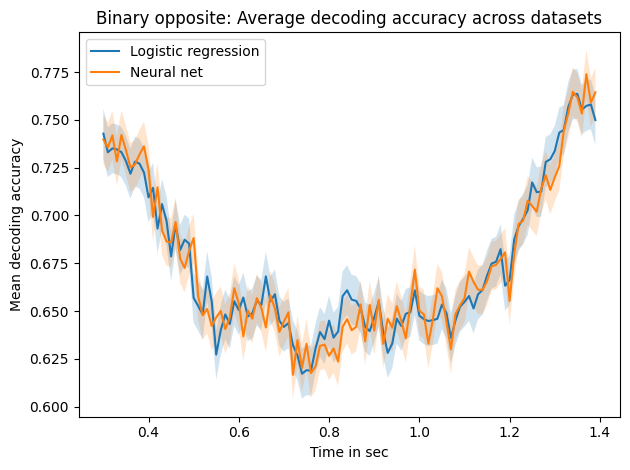

In [9]:
#plotting the total results with an error by using fill_between function since this looks nicer (alpha give the opacity)
plt.plot(time_period, mean_logreg, label="Logistic regression")
plt.fill_between(time_period, mean_logreg - sem_logreg, mean_logreg + sem_logreg, alpha=0.2)

plt.plot(time_period, mean_nn, label="Neural net")
plt.fill_between(time_period, mean_nn - sem_nn, mean_nn + sem_nn, alpha=0.2)

plt.xlabel("Time in sec")
plt.ylabel("Mean decoding accuracy")
plt.title("Binary opposite: Average decoding accuracy across datasets")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
#Print results:
dataset_mean_logreg = np.mean(all_logreg, axis=1)
dataset_mean_nn = np.mean(all_nn, axis=1)

grand_mean_logreg = np.mean(dataset_mean_logreg)
grand_mean_nn = np.mean(dataset_mean_nn)

sem_logreg = np.std(dataset_mean_logreg) / np.sqrt(len(dataset_mean_logreg))
sem_nn = np.std(dataset_mean_nn) / np.sqrt(len(dataset_mean_nn))

print(f"LogReg accuracy = {grand_mean_logreg:.3f} ± {sem_logreg:.3f}")
print(f"Neural net accuracy = {grand_mean_nn:.3f} ± {sem_nn:.3f}")
total_sem = sem_nn + sem_logreg
if np.mean(grand_mean_nn) > np.mean(grand_mean_logreg):
    print(f'Neural net outperforms by: {round(np.mean(grand_mean_nn)*100-np.mean(grand_mean_logreg)*100, 2)} ± {total_sem:.3f}%')
else:
    print(f'Logistic regression outperforms by: {round(np.mean(grand_mean_logreg)*100-np.mean(grand_mean_nn)*100, 2)} ± {total_sem:.3f} %')

LogReg accuracy = 0.675 ± 0.013
Neural net accuracy = 0.674 ± 0.013
Logistic regression outperforms by: 0.08 ± 0.026 %
